# 1. The Problem Without Tools
When users ask Claude for current information, it hits a wall. For example, if someone asks "What's the weather in San Francisco, California?" Claude has to respond with something like "I'm sorry, but I don't have access to up-to-date weather information."

### How Tool Use Works

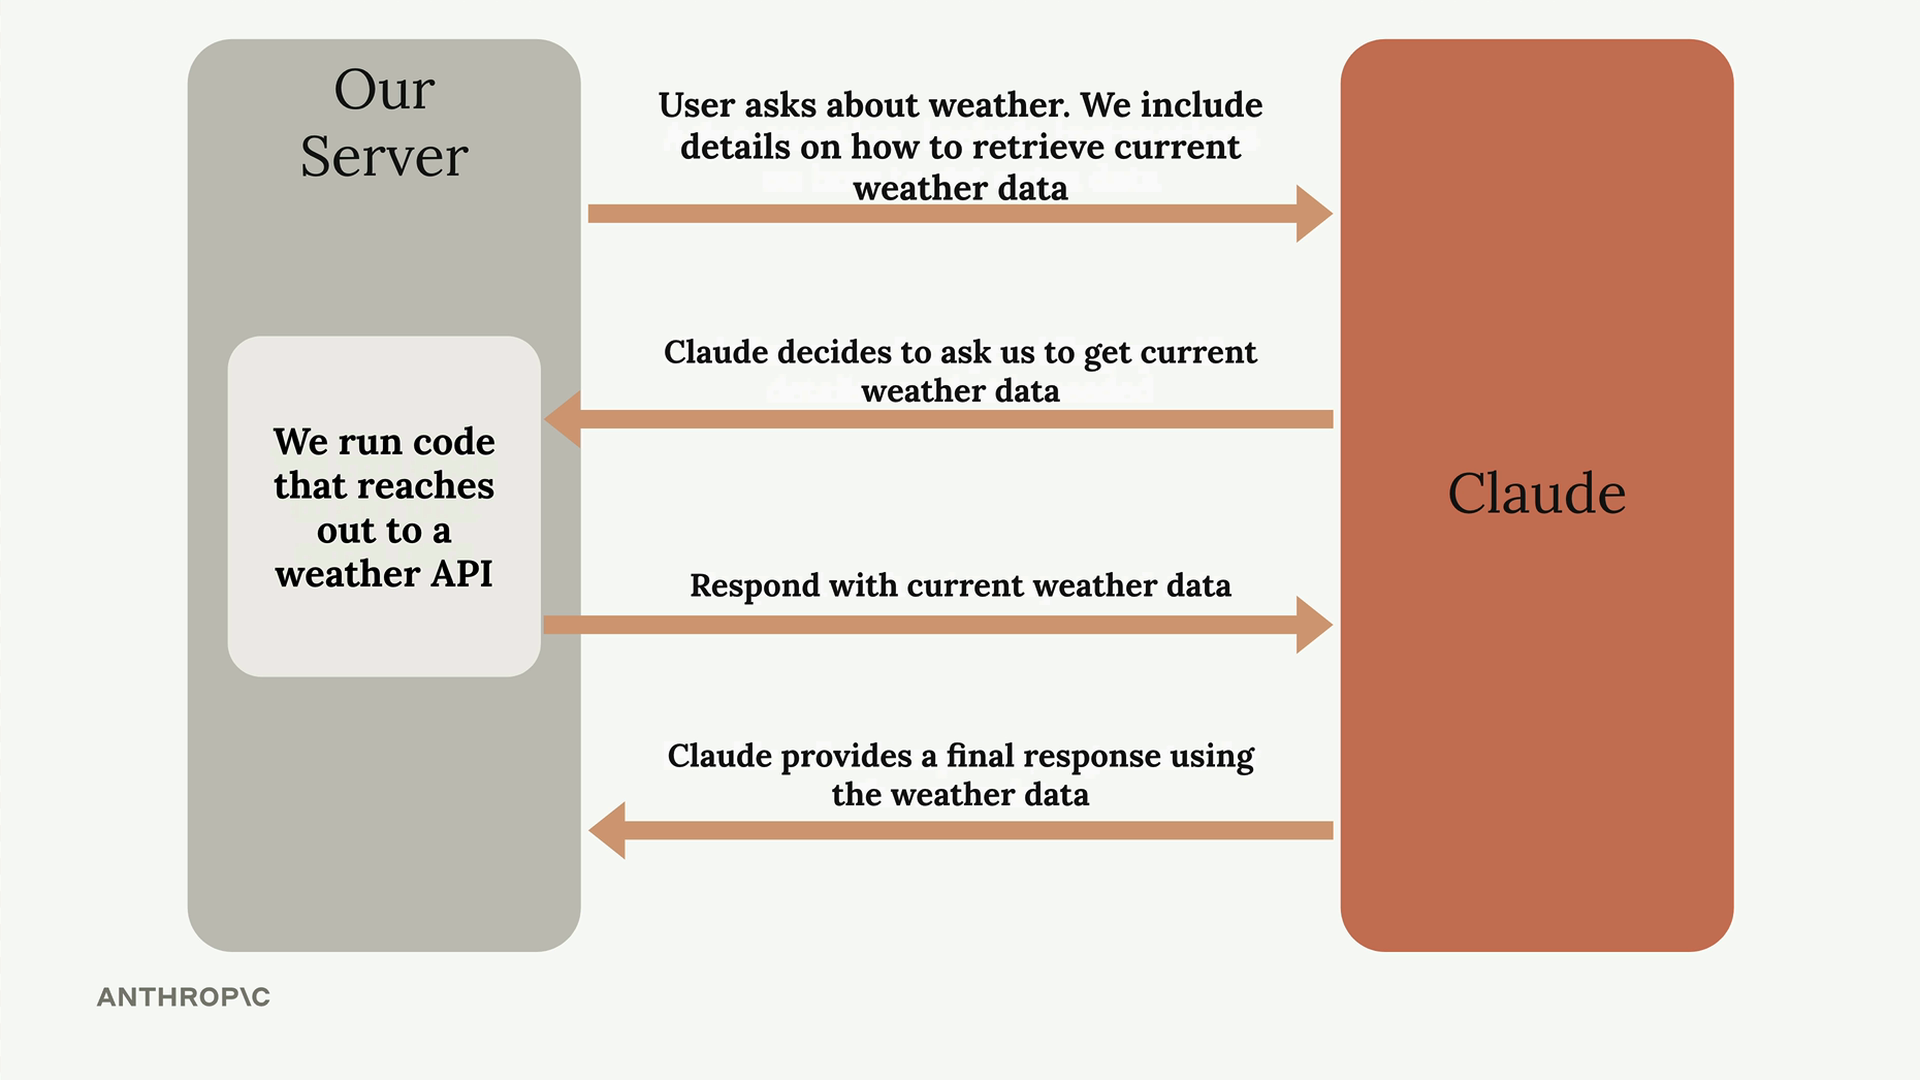
1. **Initial Request:** You send Claude a question along with instructions on how to get extra data from external sources
2. **Tool Request:** Claude analyzes the question and decides it needs additional information, then asks for specific details about what data it needs
3. **Data Retrieval:** Your server runs code to fetch the requested information from external APIs or databases
4. **Final Response:** You send the retrieved data back to Claude, which then generates a complete response using both the original question and the fresh data

# 2. Tool Functions

We're going to build a practical project that teaches Claude how to set reminders for future dates. This might sound simple at first, but it reveals several interesting challenges that we'll solve using custom tools.

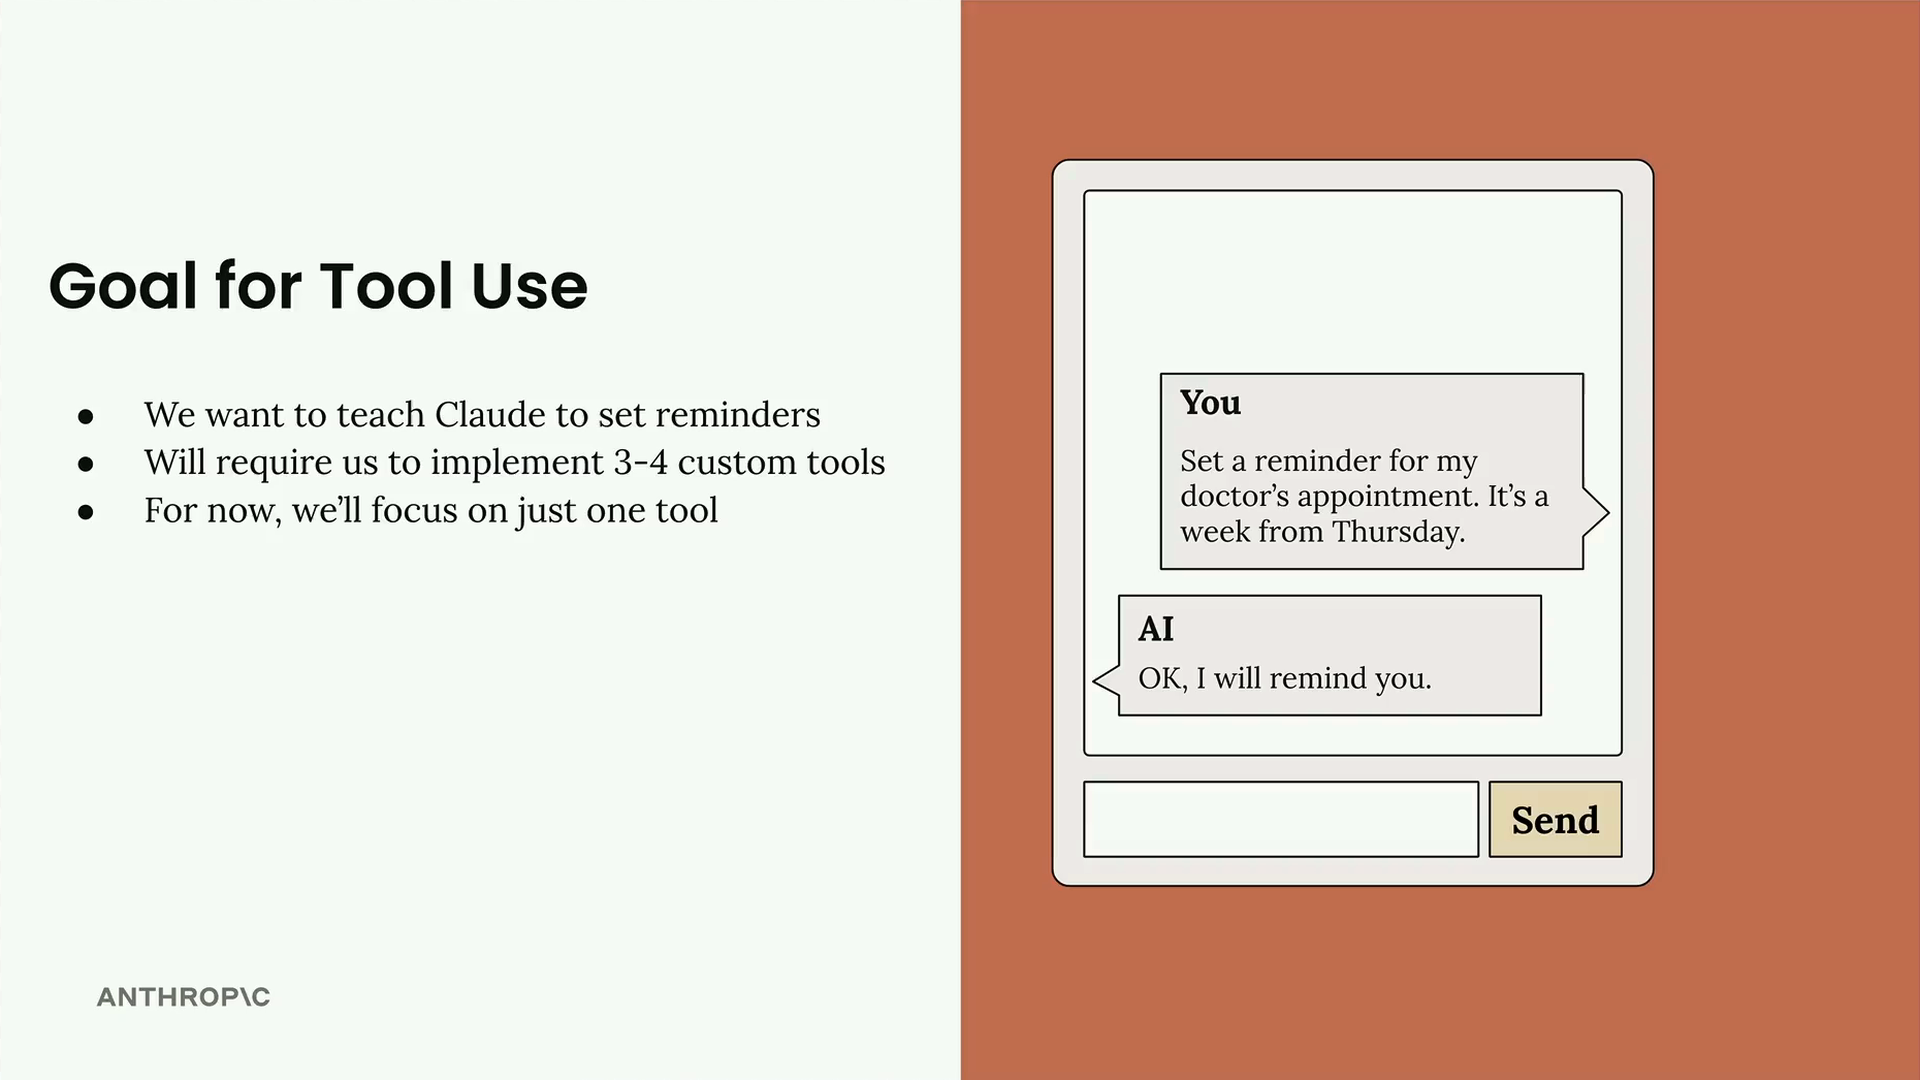

**While Claude knows the current date, there are three specific problems we need to solve:**

* **Limited time awareness:** Claude might know the current date, but not the exact time
* **Date calculation issues:** Claude doesn't always handle time-based addition well, especially when looking many days into the future
* **No reminder capability:** Claude doesn't know how to set a reminder - it has no built-in mechanism for this

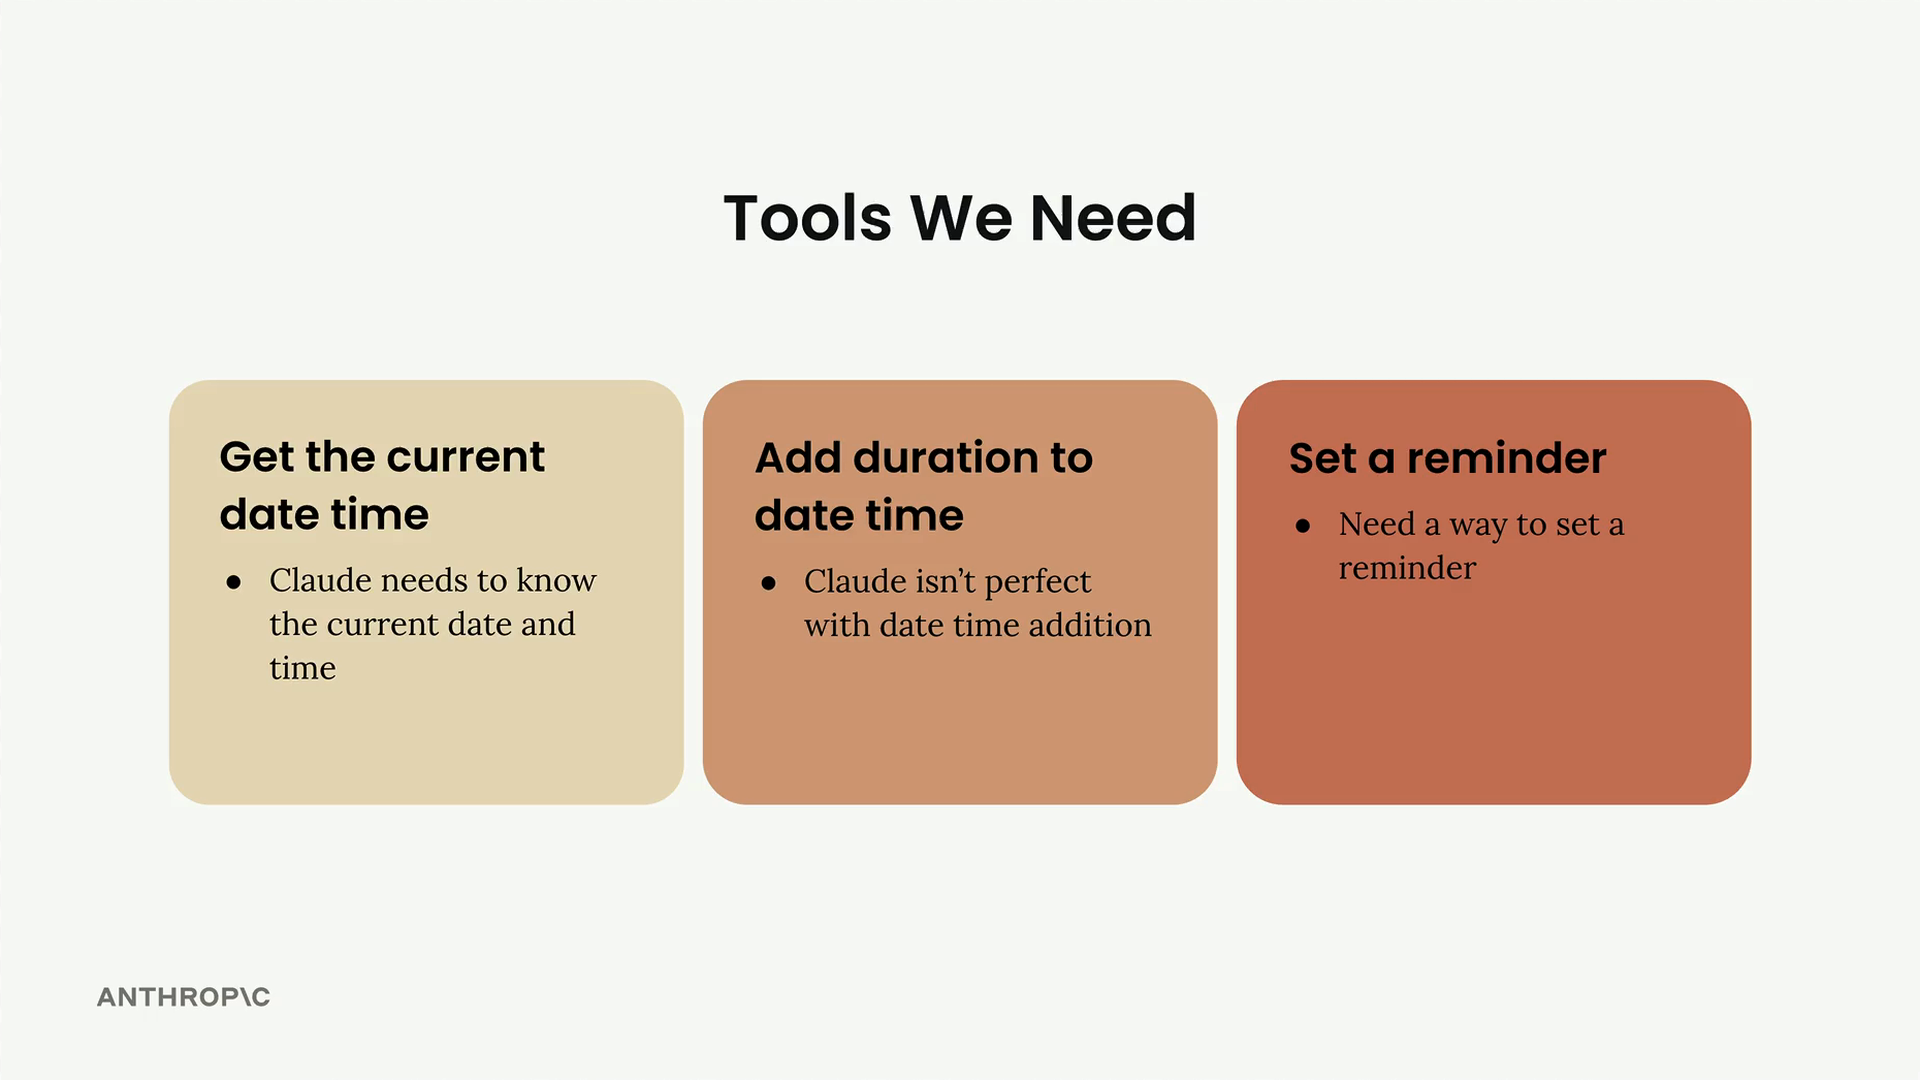

The image above shows three essential tools we'll be implementing: getting the current date/time, adding duration to dates, and setting reminders. Let's start with the first one.

In [1]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [ ]:
# Helper functions
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)


def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[]):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

In [ ]:
# Tools and Schemas

from datetime import datetime, timedelta


def add_duration_to_datetime(
    datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"
):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")


def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")


add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

#### What are Tool Functions?

**A tool function is a plain Python function that gets executed automatically when Claude decides it needs extra information to help a user.**  
For example, if someone asks "What time is it?", Claude would call your date/time tool to get the current time.

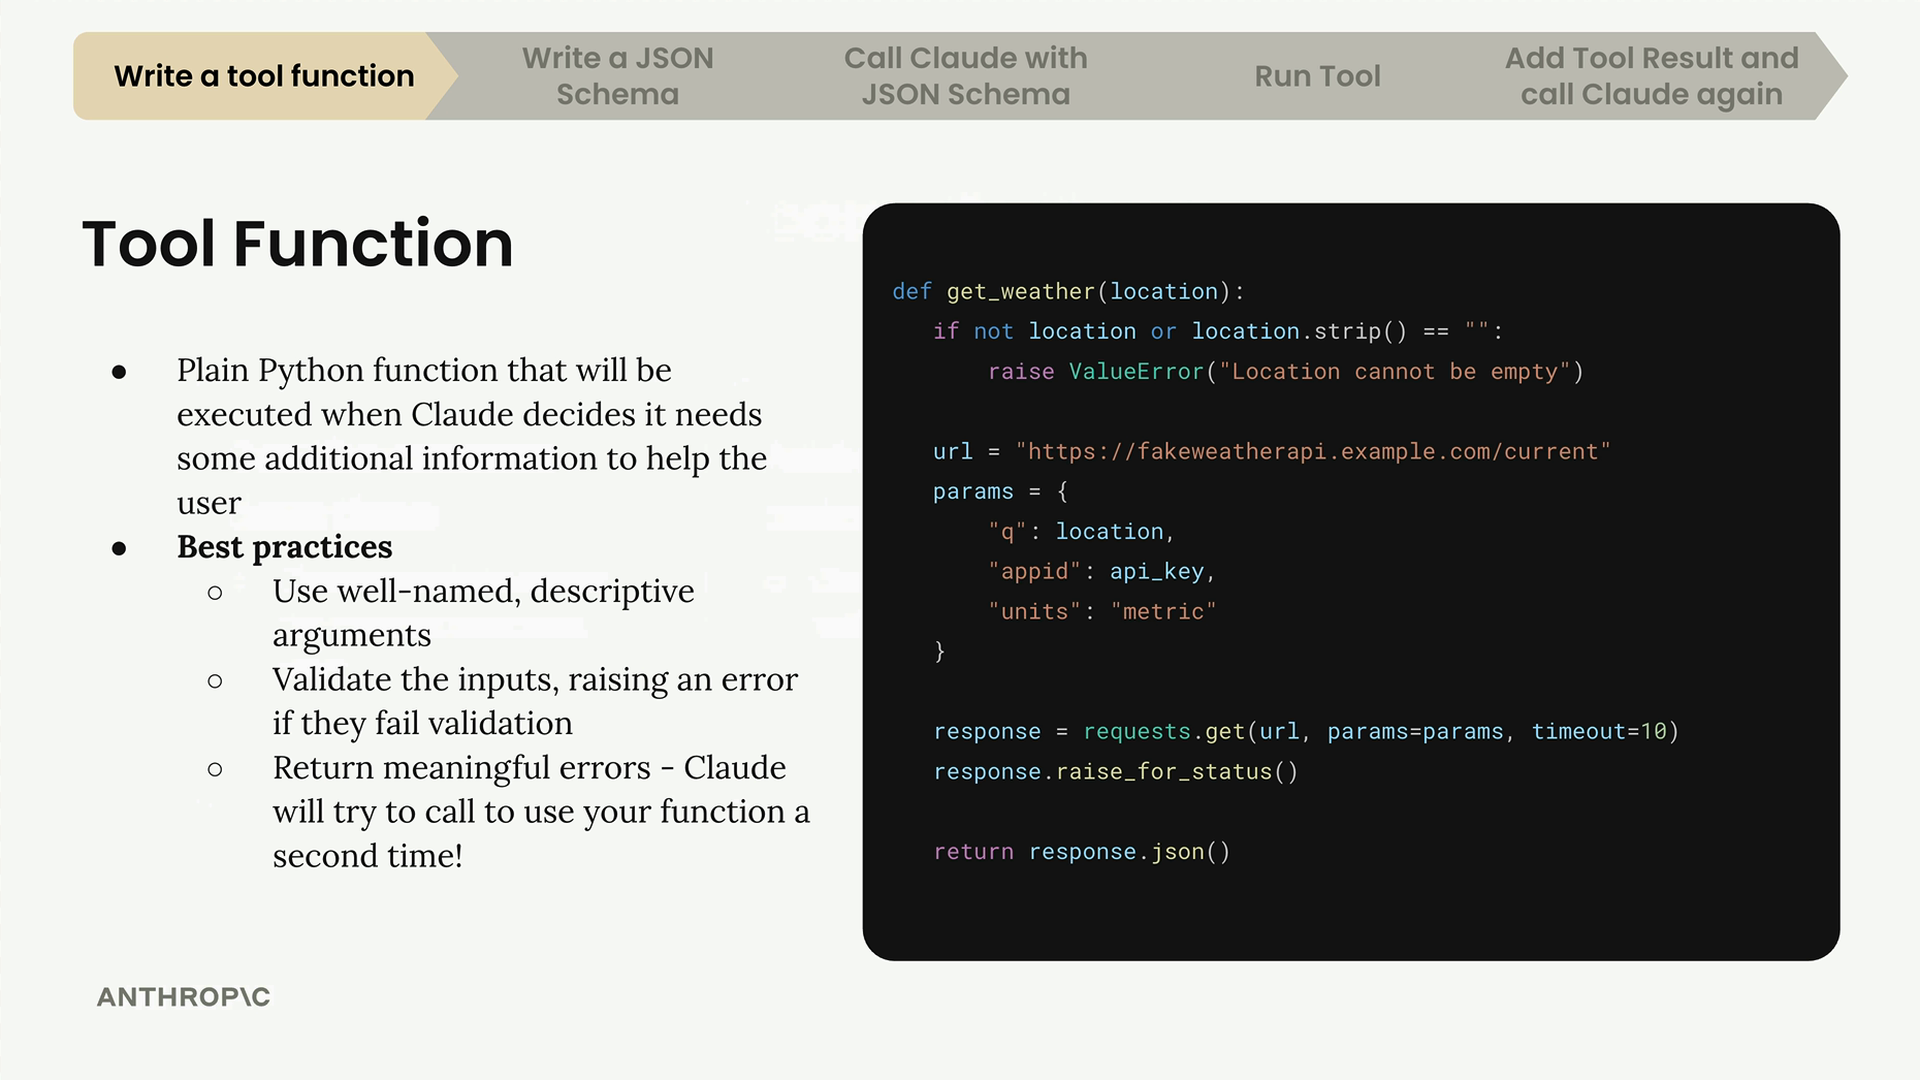

* Here's an example of a weather tool function. Notice how it validates inputs and provides clear error messages - these are important best practices.

# 3. Tool Schemas
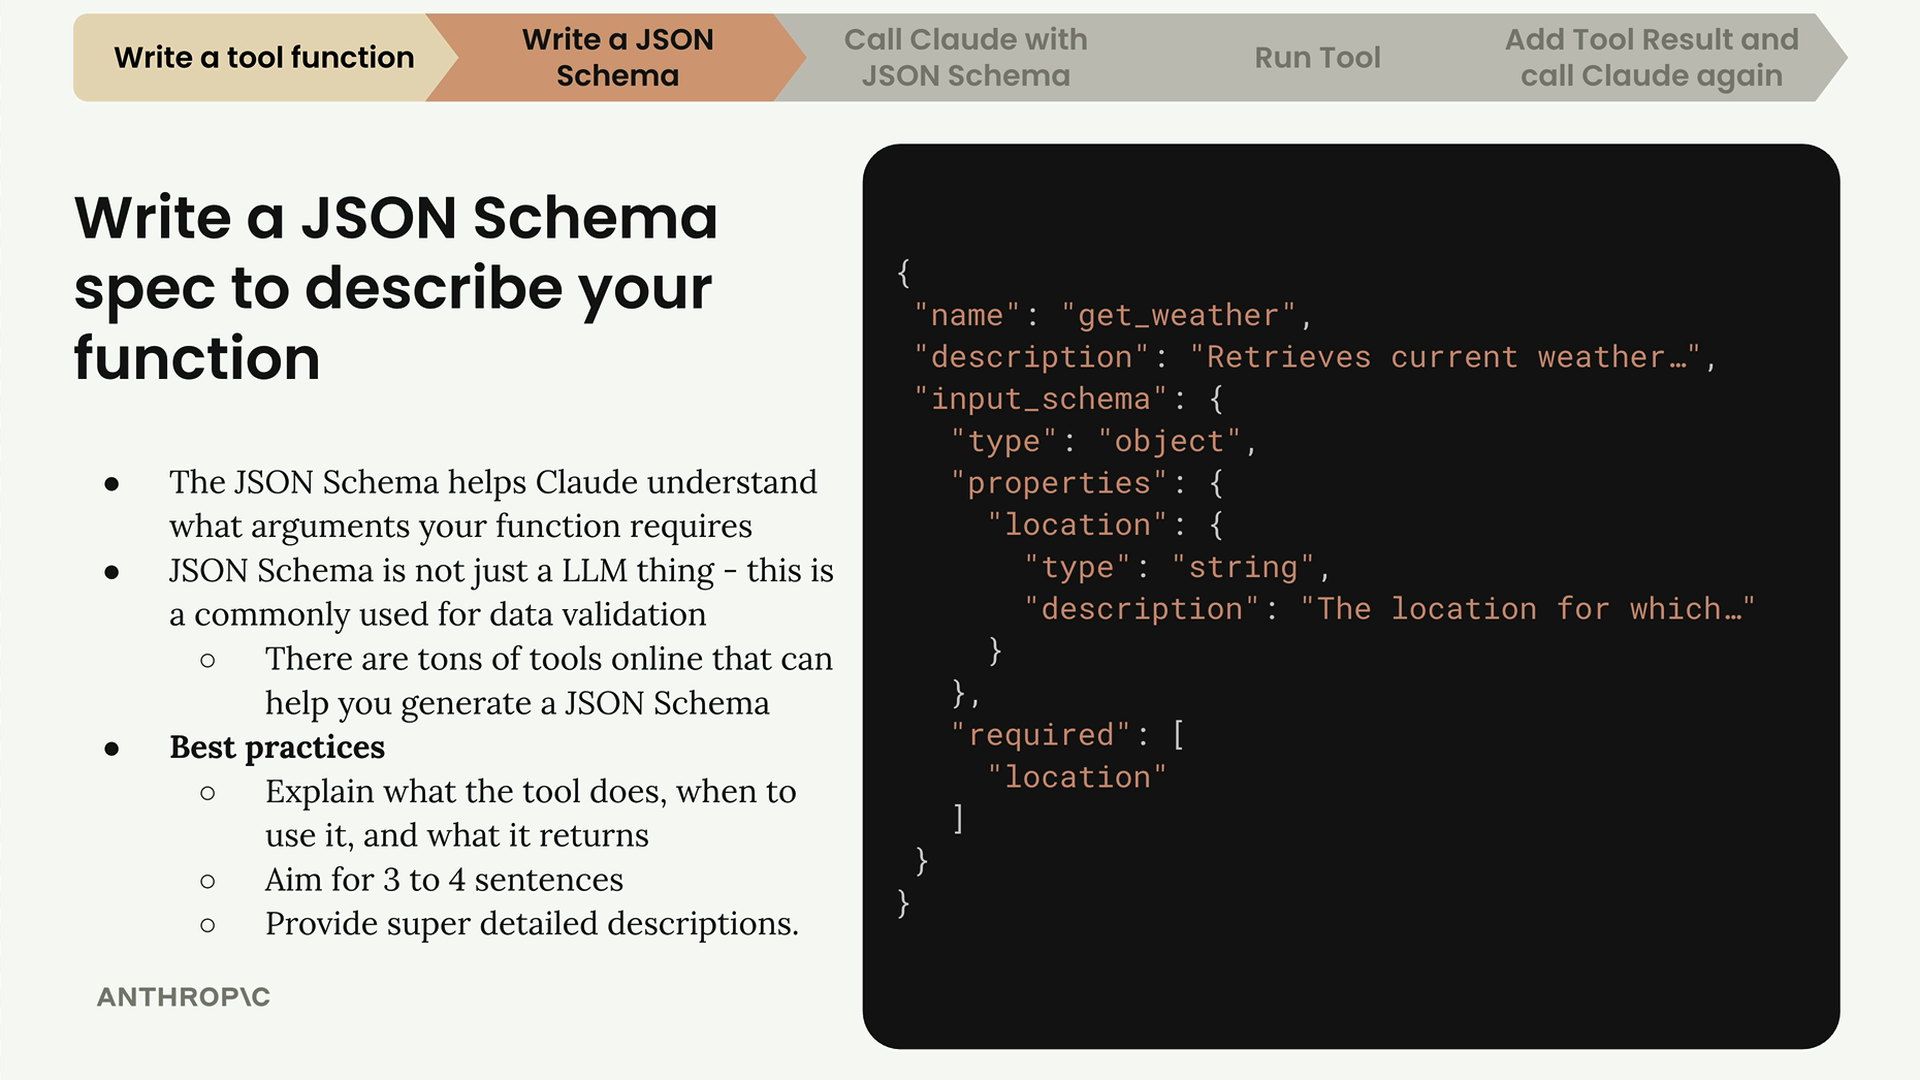

The complete tool specification has three main parts:

* **name** - A clear, descriptive name for your tool (like "get_weather")
* **description** - What the tool does, when to use it, and what it returns
* **input_schema** - The actual JSON schema describing the function's arguments

#### Writing Effective Descriptions

Your tool description is crucial for helping Claude understand when to use your function. Best practices include:

* Aim for 3-4 sentences explaining what the tool does
* Describe when Claude should use it
* Explain what kind of data it returns
* Provide detailed descriptions for each argument

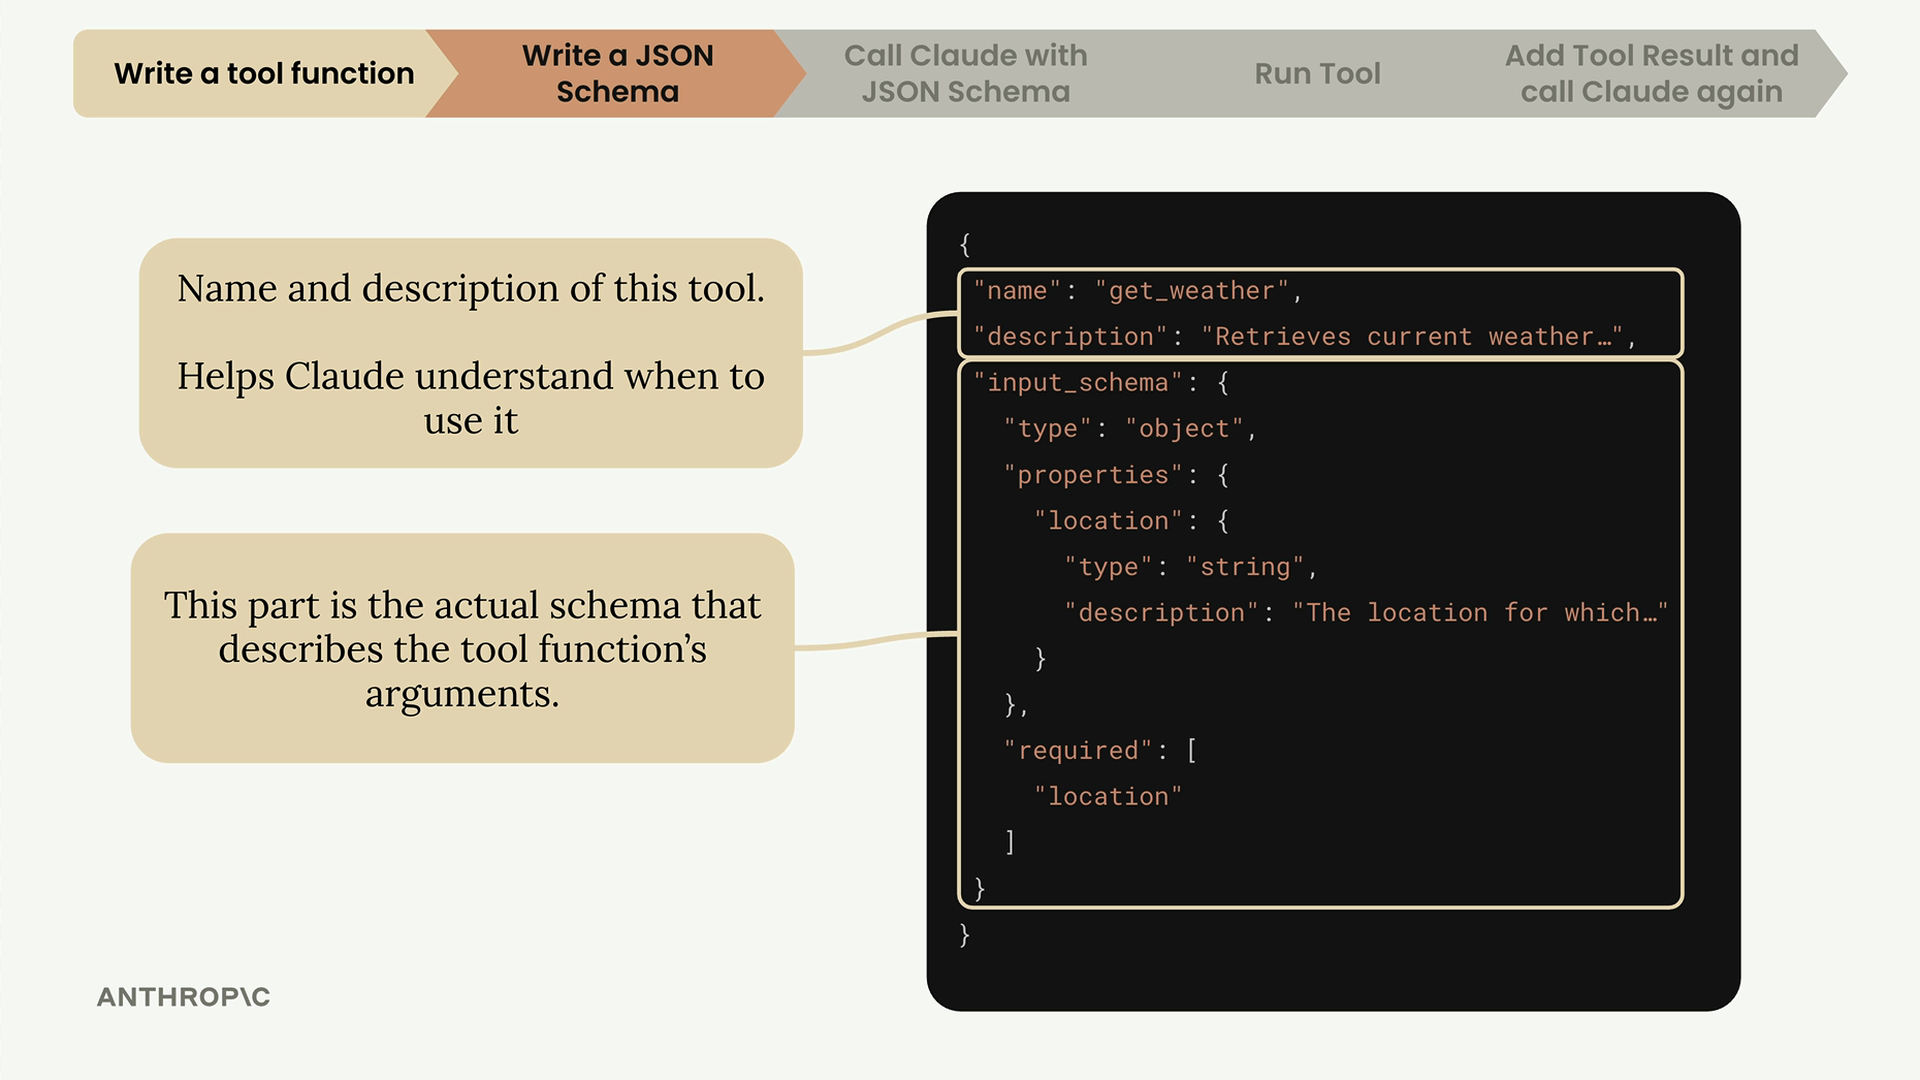

### Generate Schemas
Instead of writing JSON schemas from scratch, you can use Claude itself to generate them. Here's the process:

1. Copy your tool function code
2. Go to Claude and ask it to write a JSON schema for tool calling
3. Include the Anthropic documentation on tool use as context
4. Let Claude generate a properly formatted schema following best practices

The prompt should be something like: 
```
"Write a valid JSON schema spec for the purposes of tool calling for this function. Follow the best practices listed in the attached documentation."
```

#### Implementing the Schema in Code
Once Claude generates your schema, copy it into your code file. Here's a good naming pattern to follow:

In [ ]:
def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("date_format cannot be empty")
    return datetime.now().strftime(date_format)

get_current_datetime_schema = {
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A string specifying the format of the returned datetime. Uses Python's strftime format codes.",
                "default": "%Y-%m-%d %H:%M:%S"
            }
        },
        "required": []
    }
}

Use the pattern of `function_name` followed by `function_name_schema` to keep your schemas organized and easy to match with their corresponding functions.

#### Adding Type Safety
For better type checking, import and use the `ToolParam` type from the Anthropic library. While not strictly necessary for functionality, this prevents type errors when you use the schema with Claude's API and makes your code more robust.

In [ ]:
from anthropic.types import ToolParam

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    # ... rest of schema
})